In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/japan_cleaned_data.csv")

df.head()


,Year,Total_Population,Elderly_Percent,GDP,Fertility_Rate
0,1990,123478000.0,12.159237,3.185905e+12,1.54
1,1991,123964000.0,12.642663,3.648066e+12,1.53
2,1992,124425000.0,13.146100,3.980703e+12,1.50
3,1993,124829000.0,13.645147,4.536940e+12,1.46
4,1994,125178000.0,14.147171,4.998798e+12,1.50


In [3]:
df["Elderly_Population"] = (
    df["Elderly_Percent"] / 100
) * df["Total_Population"]

df.head()


,Year,Total_Population,Elderly_Percent,GDP,Fertility_Rate,Elderly_Population
0,1990,123478000.0,12.159237,3.185905e+12,1.54,1.501398e+07
1,1991,123964000.0,12.642663,3.648066e+12,1.53,1.567235e+07
2,1992,124425000.0,13.146100,3.980703e+12,1.50,1.635703e+07
3,1993,124829000.0,13.645147,4.536940e+12,1.46,1.703310e+07
4,1994,125178000.0,14.147171,4.998798e+12,1.50,1.770915e+07


In [4]:
df["Working_Age_Population"] = (
    df["Total_Population"] - df["Elderly_Population"]
)

df.head()


,Year,Total_Population,Elderly_Percent,GDP,Fertility_Rate,Elderly_Population,Working_Age_Population
0,1990,123478000.0,12.159237,3.185905e+12,1.54,1.501398e+07,1.084640e+08
1,1991,123964000.0,12.642663,3.648066e+12,1.53,1.567235e+07,1.082916e+08
2,1992,124425000.0,13.146100,3.980703e+12,1.50,1.635703e+07,1.080680e+08
3,1993,124829000.0,13.645147,4.536940e+12,1.46,1.703310e+07,1.077959e+08
4,1994,125178000.0,14.147171,4.998798e+12,1.50,1.770915e+07,1.074689e+08


In [5]:
df["Dependency_Ratio"] = (
    df["Elderly_Population"] /
    df["Working_Age_Population"]
)

df.head()


,Year,Total_Population,Elderly_Percent,GDP,Fertility_Rate,Elderly_Population,Working_Age_Population,Dependency_Ratio
0,1990,123478000.0,12.159237,3.185905e+12,1.54,1.501398e+07,1.084640e+08,0.138424
1,1991,123964000.0,12.642663,3.648066e+12,1.53,1.567235e+07,1.082916e+08,0.144724
2,1992,124425000.0,13.146100,3.980703e+12,1.50,1.635703e+07,1.080680e+08,0.151359
3,1993,124829000.0,13.645147,4.536940e+12,1.46,1.703310e+07,1.077959e+08,0.158013
4,1994,125178000.0,14.147171,4.998798e+12,1.50,1.770915e+07,1.074689e+08,0.164784


In [6]:
df["GDP_Per_Capita"] = (
    df["GDP"] /
    df["Total_Population"]
)

df.head()


,Year,Total_Population,Elderly_Percent,GDP,Fertility_Rate,Elderly_Population,Working_Age_Population,Dependency_Ratio,GDP_Per_Capita
0,1990,123478000.0,12.159237,3.185905e+12,1.54,1.501398e+07,1.084640e+08,0.138424,25801.395039
1,1991,123964000.0,12.642663,3.648066e+12,1.53,1.567235e+07,1.082916e+08,0.144724,29428.428904
2,1992,124425000.0,13.146100,3.980703e+12,1.50,1.635703e+07,1.080680e+08,0.151359,31992.790212
3,1993,124829000.0,13.645147,4.536940e+12,1.46,1.703310e+07,1.077959e+08,0.158013,36345.244126
4,1994,125178000.0,14.147171,4.998798e+12,1.50,1.770915e+07,1.074689e+08,0.164784,39933.515056


In [7]:
df["Population_Growth_Rate"] = (
    df["Total_Population"].pct_change()
)

df.head()


,Year,Total_Population,Elderly_Percent,GDP,Fertility_Rate,Elderly_Population,Working_Age_Population,Dependency_Ratio,GDP_Per_Capita,Population_Growth_Rate
0,1990,123478000.0,12.159237,3.185905e+12,1.54,1.501398e+07,1.084640e+08,0.138424,25801.395039,NaN
1,1991,123964000.0,12.642663,3.648066e+12,1.53,1.567235e+07,1.082916e+08,0.144724,29428.428904,0.003936
2,1992,124425000.0,13.146100,3.980703e+12,1.50,1.635703e+07,1.080680e+08,0.151359,31992.790212,0.003719
3,1993,124829000.0,13.645147,4.536940e+12,1.46,1.703310e+07,1.077959e+08,0.158013,36345.244126,0.003247
4,1994,125178000.0,14.147171,4.998798e+12,1.50,1.770915e+07,1.074689e+08,0.164784,39933.515056,0.002796


In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

risk_features = df[[
    "Elderly_Percent",
    "Dependency_Ratio",
    "Population_Growth_Rate"
]]

scaled = scaler.fit_transform(risk_features)

df[[
    "Elderly_scaled",
    "Dependency_scaled",
    "PopGrowth_scaled"
]] = scaled


In [9]:
df["Demographic_Risk_Score"] = (
    0.4 * df["Elderly_scaled"] +
    0.4 * df["Dependency_scaled"] +
    0.2 * (1 - df["PopGrowth_scaled"])
) * 100

df.head()


,Year,Total_Population,Elderly_Percent,GDP,Fertility_Rate,Elderly_Population,Working_Age_Population,Dependency_Ratio,GDP_Per_Capita,Population_Growth_Rate,Elderly_scaled,Dependency_scaled,PopGrowth_scaled,Demographic_Risk_Score
0,1990,123478000.0,12.159237,3.185905e+12,1.54,1.501398e+07,1.084640e+08,0.138424,25801.395039,NaN,0.000000,0.000000,NaN,NaN
1,1991,123964000.0,12.642663,3.648066e+12,1.53,1.567235e+07,1.082916e+08,0.144724,29428.428904,0.003936,0.027434,0.022052,1.000000,1.979421
2,1992,124425000.0,13.146100,3.980703e+12,1.50,1.635703e+07,1.080680e+08,0.151359,31992.790212,0.003719,0.056003,0.045277,0.975323,4.544757
3,1993,124829000.0,13.645147,4.536940e+12,1.46,1.703310e+07,1.077959e+08,0.158013,36345.244126,0.003247,0.084324,0.068567,0.921686,7.681918
4,1994,125178000.0,14.147171,4.998798e+12,1.50,1.770915e+07,1.074689e+08,0.164784,39933.515056,0.002796,0.112813,0.092270,0.870411,10.795092


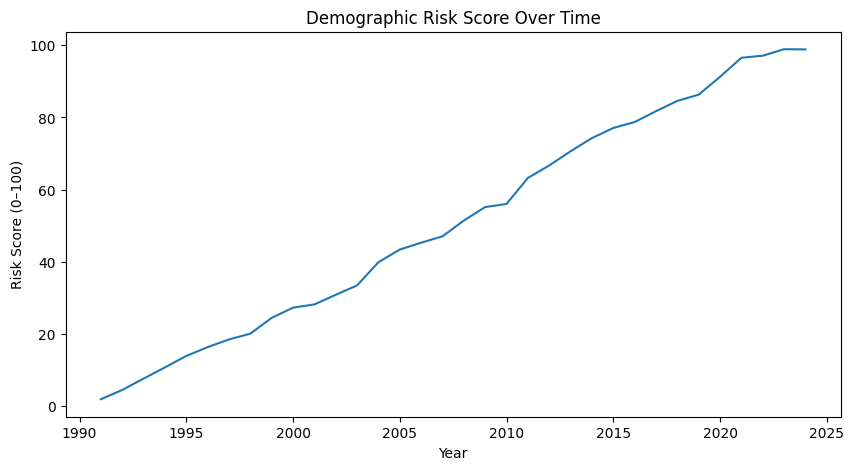

In [10]:
plt.figure(figsize=(10,5))
plt.plot(df["Year"], df["Demographic_Risk_Score"])
plt.title("Demographic Risk Score Over Time")
plt.xlabel("Year")
plt.ylabel("Risk Score (0–100)")
plt.show()


In [11]:
df.to_csv("../data/processed/japan_feature_engineered.csv", index=False)
